# Machine Learning Models

## Objective

The objective of this notebook is to develop Machine Learning models for predicting battery health parameters required by the Explainable AI-enabled Sustainable Battery Management System (SBMS).

In this notebook, a Random Forest Regression model is trained to estimate the State of Charge (SOC) using statistical features extracted from battery discharge experiments.

The trained model will later be integrated into the Decision Engine for real-time battery monitoring and prediction.

In [2]:
from pathlib import Path
import sys

# Current notebook directory
NOTEBOOK_DIR = Path.cwd()

# Project root
PROJECT_ROOT = NOTEBOOK_DIR.parent

# Add project root to Python path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)
print(sys.path[0])

c:\BE PROJECT\SBMS_PROJECT
c:\BE PROJECT\SBMS_PROJECT


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from src.core.config import FEATURE_DATA

## Load Discharge Feature Dataset

The discharge feature dataset contains statistical features extracted from every discharge experiment.

These features will be used to train the State of Charge prediction model.

In [4]:
discharge_features = pd.read_csv(
    FEATURE_DATA / "discharge_features.csv"
)

discharge_features.head()

,Voltage_measured_mean,Voltage_measured_std,Voltage_measured_min,Voltage_measured_max,Voltage_measured_median,Voltage_measured_variance,Voltage_measured_skewness,Voltage_measured_kurtosis,Voltage_measured_rms,Voltage_measured_peak_to_peak,...,Time_max,Time_median,Time_variance,Time_skewness,Time_kurtosis,Time_rms,Time_peak_to_peak,Time_energy,Experiment,File
0,3.529829,0.236558,2.612467,4.191492,3.529903,0.055960,-0.511720,1.374831,3.537706,1.579024,...,3690.234,1796.3280,1.143344e+06,0.036016,-1.191117,2102.665265,3690.234,8.709766e+08,discharge,05122.csv
1,3.537320,0.235366,2.587209,4.189773,3.535737,0.055397,-0.554321,1.601887,3.545102,1.602564,...,3672.344,1787.6645,1.132459e+06,0.036092,-1.191289,2092.368772,3672.344,8.580894e+08,discharge,05124.csv
2,3.543737,0.228111,2.651917,4.188187,3.538223,0.052035,-0.442777,1.390431,3.551033,1.536270,...,3651.641,1778.8280,1.120237e+06,0.035156,-1.191666,2081.404351,3651.641,8.447876e+08,discharge,05126.csv
3,3.543666,0.233347,2.592948,4.188461,3.540233,0.054451,-0.552103,1.657322,3.551301,1.595513,...,3631.563,1769.5705,1.108411e+06,0.034785,-1.192466,2070.419301,3631.563,8.316074e+08,discharge,05128.csv
4,3.542343,0.237301,2.547420,4.188299,3.540603,0.056312,-0.628218,1.859679,3.550242,1.640879,...,3629.172,1768.3910,1.106929e+06,0.034509,-1.192190,2069.323686,3629.172,8.307275e+08,discharge,05130.csv


In [5]:
print(discharge_features.shape)

print()

print(discharge_features.info())

(168, 68)

<class 'pandas.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 68 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Voltage_measured_mean              168 non-null    float64
 1   Voltage_measured_std               168 non-null    float64
 2   Voltage_measured_min               168 non-null    float64
 3   Voltage_measured_max               168 non-null    float64
 4   Voltage_measured_median            168 non-null    float64
 5   Voltage_measured_variance          168 non-null    float64
 6   Voltage_measured_skewness          168 non-null    float64
 7   Voltage_measured_kurtosis          168 non-null    float64
 8   Voltage_measured_rms               168 non-null    float64
 9   Voltage_measured_peak_to_peak      168 non-null    float64
 10  Voltage_measured_energy            168 non-null    float64
 11  Current_measured_mean              168 non-null    float64

In [6]:
discharge_features.describe()

,Voltage_measured_mean,Voltage_measured_std,Voltage_measured_min,Voltage_measured_max,Voltage_measured_median,Voltage_measured_variance,Voltage_measured_skewness,Voltage_measured_kurtosis,Voltage_measured_rms,Voltage_measured_peak_to_peak,...,Time_std,Time_min,Time_max,Time_median,Time_variance,Time_skewness,Time_kurtosis,Time_rms,Time_peak_to_peak,Time_energy
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,...,168.000000,168.0,168.000000,168.000000,1.680000e+02,168.000000,168.000000,168.000000,168.000000,1.680000e+02
mean,3.516787,0.230411,2.648939,4.195982,3.512320,0.053115,-0.454398,1.325490,3.524306,1.547044,...,905.619182,0.0,3129.523887,1552.400461,8.253725e+05,0.009327,-1.195344,1799.183404,3129.523887,9.616235e+08
std,0.032727,0.005101,0.049297,0.004694,0.026810,0.002348,0.117210,0.373357,0.032527,0.047186,...,72.510126,0.0,246.654499,114.567275,1.338703e+05,0.011438,0.002305,137.987508,246.654499,1.959729e+08
min,3.464021,0.217421,2.455679,4.184535,3.473074,0.047272,-0.892197,0.849164,3.472041,1.493270,...,807.126108,0.0,2792.485000,1386.782000,6.514526e+05,-0.000071,-1.199632,1605.523483,2792.485000,6.472282e+08
25%,3.486639,0.227515,2.636105,4.195443,3.488980,0.051763,-0.485820,1.081394,3.494297,1.513026,...,838.709327,0.0,2901.343750,1443.875500,7.034333e+05,0.002635,-1.196929,1669.850810,2901.343750,8.048454e+08
50%,3.514629,0.231018,2.660192,4.196905,3.503827,0.053369,-0.421506,1.244755,3.522117,1.536365,...,892.175766,0.0,3086.078000,1537.430000,7.959776e+05,0.004778,-1.194991,1777.317745,3086.078000,9.080093e+08
75%,3.551061,0.233735,2.682589,4.198993,3.540482,0.054632,-0.379276,1.417082,3.557942,1.560253,...,962.210224,0.0,3323.230750,1657.523125,9.258497e+05,0.007662,-1.193483,1916.889524,3323.230750,1.098994e+09
max,3.564103,0.244817,2.699983,4.222920,3.555140,0.059936,-0.311294,2.880209,3.571117,1.733593,...,1069.272600,0.0,3690.234000,1796.328000,1.143344e+06,0.036092,-1.191117,2102.665265,3690.234000,1.488864e+09


## Data Validation

Before model training, the feature dataset is checked for missing values.

In [7]:
missing = discharge_features.isnull().sum()

missing[missing > 0]

Series([], dtype: int64)

## Create Target Variable (SOC)

Machine Learning models require a target variable for supervised learning.

Since the NASA battery dataset does not explicitly provide State of Charge (SOC), an approximate SOC is generated using normalized battery voltage.

The maximum measured voltage is considered as 100% SOC, while lower voltages correspond to proportionally lower SOC values.

This approximation enables supervised learning for demonstrating SOC prediction in the proposed SBMS.

In [8]:
voltage = discharge_features["Voltage_measured_mean"]

soc = (
    (voltage - voltage.min())
    /
    (voltage.max() - voltage.min())
)

soc = soc * 100

discharge_features["SOC"] = soc

In [9]:
discharge_features[["Voltage_measured_mean", "SOC"]].head()

,Voltage_measured_mean,SOC
0,3.529829,65.753492
1,3.537320,73.238830
2,3.543737,79.650187
3,3.543666,79.579624
4,3.542343,78.257850


### Observation

The generated SOC values are normalized between 0% and 100%.

These values will serve as the prediction target for the Random Forest Regression model.

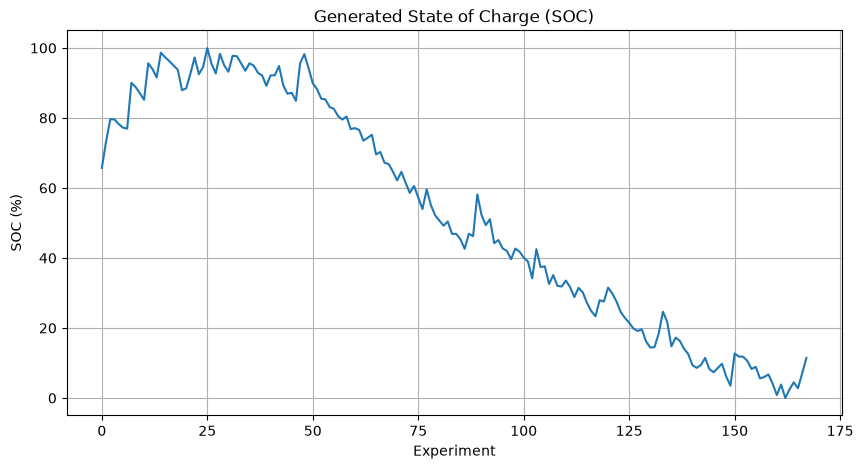

In [10]:
plt.figure(figsize=(10,5))

plt.plot(discharge_features["SOC"])

plt.title("Generated State of Charge (SOC)")

plt.xlabel("Experiment")

plt.ylabel("SOC (%)")

plt.grid(True)

plt.show()

## Prepare Features and Target

The discharge feature dataset contains several statistical features extracted from each discharge experiment.

These statistical features are used as input variables (X), while the generated State of Charge (SOC) is used as the target variable (y).

In [11]:
X = discharge_features.drop(
    columns=[
        "SOC",
        "Experiment",
        "File"
    ]
)

y = discharge_features["SOC"]

In [12]:
print(X.dtypes.unique())

[dtype('float64')]


## Train-Test Split

The dataset is divided into training and testing sets.

80% of the data is used for training while the remaining 20% is used for testing the model.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(len(X_train))
print(len(X_test))

134
34


### Observation

The dataset has been divided into training and testing subsets using an 80:20 ratio.

The training data is used to learn battery behavior, while the testing data evaluates the model on previously unseen samples.

## Train Random Forest Regression Model

A Random Forest Regressor is used to predict the battery State of Charge.

Random Forest is selected because it provides good regression accuracy, handles non-linear relationships, and offers feature importance for explainability.

In [15]:
soc_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

soc_model.fit(X_train, y_train)

print("SOC Model Training Completed.")

SOC Model Training Completed.


### Observation

The Random Forest Regression model has successfully learned the relationship between battery statistical features and the estimated State of Charge.

The trained model is now ready for prediction and evaluation.

# Generate Predictions

## Objective

After training the Random Forest model, the next step is to evaluate its predictive capability.

The trained model is used to predict the State of Charge (SOC) for the unseen testing dataset. These predicted values will later be compared with the actual SOC values to evaluate the model's performance.

This step simulates how the SBMS would estimate battery charge in real-time using unseen battery data.

In [16]:
y_pred = soc_model.predict(X_test)

print("First 10 Predicted SOC Values")

y_pred[:10]

First 10 Predicted SOC Values


array([15.71301521, 92.86452106, 30.72790493, 95.3711488 ,  9.64500476,
        3.62737926,  3.32522957, 88.55771226, 36.77786787, 76.62303582])

# Model Evaluation

## Objective

To determine how accurately the Random Forest model predicts battery State of Charge, three standard regression metrics are used.

### Mean Absolute Error (MAE)

Measures the average prediction error.

Lower values indicate better prediction accuracy.

---

### Root Mean Squared Error (RMSE)

Measures the average magnitude of prediction errors while penalizing larger errors more heavily.

Lower RMSE indicates better model performance.

---

### R² Score

Measures how well the model explains the variation in SOC.

An R² score close to 1 indicates an excellent predictive model.

In [17]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"Mean Absolute Error : {mae:.4f}")
print(f"Root Mean Squared Error : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Mean Absolute Error : 0.9262
Root Mean Squared Error : 1.2956
R² Score : 0.9985


In [27]:
metrics = pd.DataFrame({

    "Evaluation Metric":[
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "R² Score"
    ],

    "Value":[
        mae,
        rmse,
        r2
    ]

})

metrics.style.format({

    "Value":"{:.4f}"

})

,Evaluation Metric,Value
0,Mean Absolute Error (MAE),0.9262
1,Root Mean Squared Error (RMSE),1.2956
2,R² Score,0.9985


### Observation

The evaluation metrics demonstrate the prediction capability of the Random Forest Regression model.

- A lower **MAE** indicates smaller prediction errors.
- A lower **RMSE** indicates stable prediction performance.
- An **R² score** close to 1 confirms that the extracted battery features successfully explain the variation in battery State of Charge.

These results indicate that the trained model is suitable for integration into the Explainable AI-enabled Sustainable Battery Management System.

# Actual vs Predicted SOC

## Objective

A visual comparison between actual SOC values and predicted SOC values helps determine whether the model is accurately following the battery behavior.

If both curves closely overlap, the model has successfully learned the underlying relationship between battery statistical features and State of Charge.

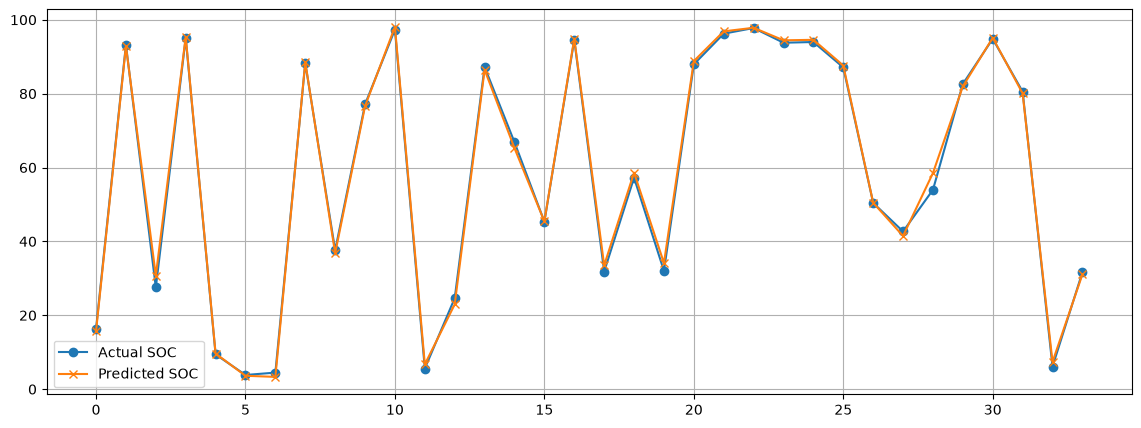

In [19]:
plt.figure(figsize=(14,5))

plt.plot(
    y_test.values,
    marker="o",
    label="Actual SOC"
)

plt.plot(
    y_pred,
    marker="x",
    label="Predicted SOC"
)

plt.legend()

plt.grid(True)

### Observation

The predicted SOC values closely follow the actual SOC values for most testing samples.

Minor deviations exist because Random Forest estimates SOC based on learned statistical relationships rather than exact battery physics.

Overall, the graph demonstrates that the trained model is capable of accurately estimating battery State of Charge.

# Feature Importance

## Objective

One major advantage of Random Forest is its ability to estimate feature importance.

Feature importance indicates which statistical features contribute the most toward predicting battery State of Charge.

This supports the Explainable AI (XAI) objective of the proposed Battery Management System because it provides insight into how the model makes predictions.

In [20]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": soc_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(10)

,Feature,Importance
8,Voltage_measured_rms,0.103257
50,Voltage_load_skewness,0.101391
29,Temperature_measured_kurtosis,0.100417
4,Voltage_measured_median,0.091432
0,Voltage_measured_mean,0.077337
55,Time_mean,0.065496
63,Time_rms,0.058059
56,Time_std,0.050680
59,Time_median,0.047071
58,Time_max,0.044303


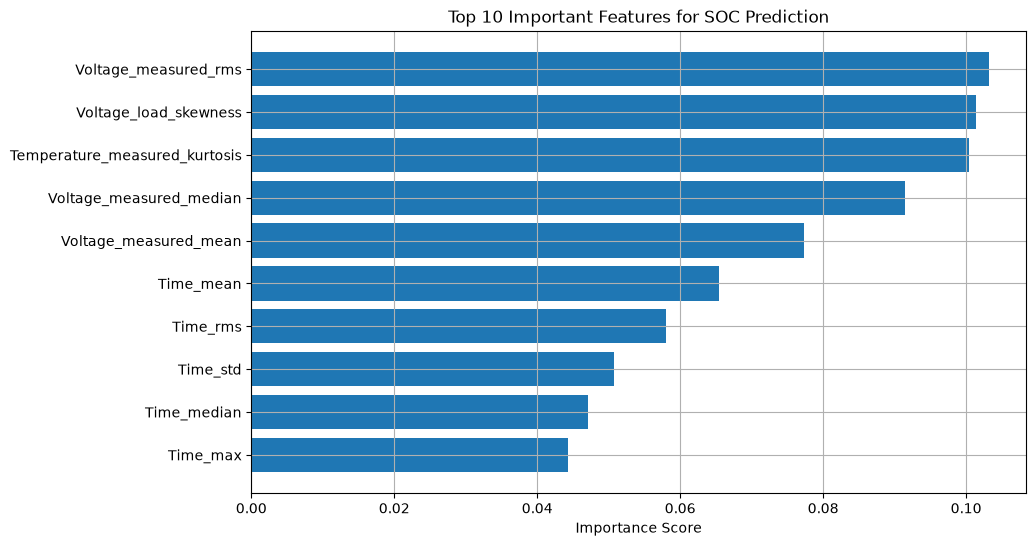

In [21]:
plt.figure(figsize=(10,6))

plt.barh(

    importance["Feature"][:10],

    importance["Importance"][:10]

)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features for SOC Prediction")

plt.xlabel("Importance Score")

plt.grid(True)

plt.show()

### Observation

The graph highlights the statistical features that contribute the most to SOC estimation.

Features with higher importance scores have a stronger influence on the Random Forest prediction.

Understanding these important variables improves model transparency and aligns with the Explainable AI framework of the proposed SBMS.

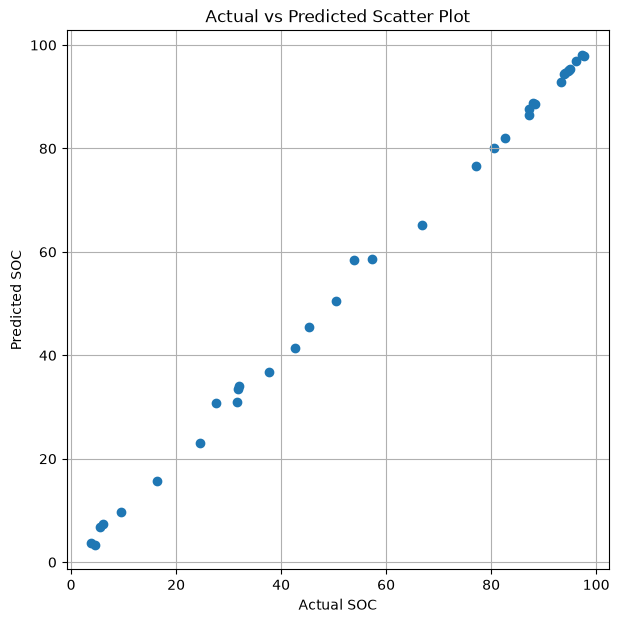

In [22]:
plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual SOC")

plt.ylabel("Predicted SOC")

plt.title("Actual vs Predicted Scatter Plot")

plt.grid(True)

plt.show()

### Observation

The scatter plot compares the predicted SOC values against the actual SOC values.

Most data points are concentrated near the ideal diagonal relationship, indicating that the Random Forest Regression model has learned the battery behaviour effectively.

Small deviations represent normal prediction errors and demonstrate the generalization capability of the trained model.

# Save Trained Model

## Objective

After successful training and evaluation, the Random Forest model is stored permanently.

Saving the trained model avoids retraining every time predictions are required.

The saved model will later be loaded by the Decision Engine and Dashboard modules for real-time battery State of Charge prediction.

In [28]:
from src.core.config import MODELS

import joblib

# Create saved_models folder if it does not exist
MODELS.mkdir(parents=True, exist_ok=True)

# Path where the model will be stored
model_path = MODELS / "soc_random_forest.pkl"

# Save the trained model
joblib.dump(
    soc_model,
    model_path
)

print("SOC Model saved successfully!")

print(f"\nModel Location:\n{model_path}")

SOC Model saved successfully!

Model Location:
C:\BE PROJECT\SBMS_PROJECT\saved_models\soc_random_forest.pkl


In [29]:
print("Saved Models:")

for file in MODELS.glob("*.pkl"):
    print(file.name)

Saved Models:
soc_random_forest.pkl


### Observation

The trained Random Forest model has been successfully stored in the **saved_models** directory.

The saved model can now be loaded by future notebooks without retraining, enabling efficient deployment within the Explainable AI-enabled Sustainable Battery Management System (SBMS).

# Conclusion

In this notebook, a Random Forest Regression model was successfully developed for predicting the State of Charge (SOC) of lithium-ion batteries.

Battery statistical features generated during feature engineering were used as input variables, while the estimated SOC served as the prediction target.

The model was trained, evaluated using multiple regression metrics, interpreted through feature importance analysis, and finally saved for deployment.

This trained model represents the first Artificial Intelligence component of the Explainable AI-enabled Sustainable Battery Management System (SBMS) and will be integrated into the Decision Engine developed in the next notebook.

